### **Installation des packages (librairies) :**

In [ ]:
! pip install -r /workspaces/Heatmap-of-correlation-between-BRVM-equities/requirements.txt

In [26]:
import brvmfinance as bf           #On importe brvmfinance afin d'accéder aux données financières de la BRVM
import matplotlib.pyplot as plt    #On importe matplotlib.pyplot afin de visualiser les données financières de la BRVM
import pandas as pd                #On importe pandas afin de gérer les Data Frames des données financières
import seaborn as sns              #On importe seaborn afin de visualiser nos données de manière plus esthétique

### 0) Téléchargement :

- Pour télécharger nos données on se servira du package python **brvmfinance** avec ses fonctions :

```
Ticker(str) 
history(int) 
```

In [ ]:
# Nous commençons par déclarer notre variable tick comme notre ticker
tick = "BOAC"

# On crée l'objet ticker
tickers  = bf.Ticker(tick)

# On charge notre l'historique de notre ticker pour les n derniers jours
n = 100
df = tickers.history(length = n)

# On affiche le Data Frame
df.head(3)

,Open,High,Low,Close,Volume
Date,,,,,
2026-06-17,9000,9090,9000,9090,9473
2026-06-18,9090,9090,9055,9055,8989
2026-06-19,9500,9500,9350,9350,5157


---

### 1) Fonction de chargement pour plusieurs tickers :

- Jusque là nous avons téléchargé l'historique d'une seul action. Dans le cas où nous voudrions l'historique d'une ou de **plusieurs** actions, nous allons créer la fonction :

```
download_tickers(ticker(s) : list[str], time : int, OHLC : str = "close") -> pd.DataFrame
```

In [ ]:
def download_tickers(tickers : list[str], time : int, pct : bool = True, OHLC : str = "Close") -> pd.DataFrame :

    # On crée une liste vide pour stocker le DataFrames de chaque ticker
  names = []

    # La boucle for télécharge le dataframe de chaque ticker et l'ajoute à la liste names avec le nom du ticker comme nom de colonne 
  for ticker in tickers :

      tick = bf.Ticker(ticker)
      if pct == True :
        dfi = tick.history(length = time)[OHLC].pct_change()
      else :
        dfi = tick.history(length = time)[OHLC]
      dfi.columns = [ticker]

      names.append(dfi)

  # On concatène les dataframes de chaque ticker en un seul dataframe avec les noms des tickers comme nom de chaque colonnes
  df = pd.concat(names, axis=1)
  df.columns = tickers

    # La sortie sera un dataframe composé de l'historique de chaque ticker
  return df

#### Test : download_tickers()

In [5]:
df = download_tickers(["BOAC", "BOAN"], 100)

df.head(3)

,BOAC,BOAN
Date,,
2026-06-17,NaN,NaN
2026-06-18,-0.003850,-0.014628
2026-06-19,0.032579,0.014845


---

### 2) Matrice de corrélation :

Afin de réaliser une matrice de corrélation, on utilise la fonction native de python :
```
corr()
```

Notre Data Frame deviendra une matrice de corrélation N², d'où N est le nombre d'actions.

In [15]:
matrice_corr = df.corr()
matrice_corr

,BOAC,BOAN
BOAC,1.000000,0.182261
BOAN,0.182261,1.000000


---

### 3) Heat Map :

- Il s'agit sans doute de la partie la plus attendue.

Pour la heat map on se servira de la fonction :
```
seaborn.heatmap()
```


Text(0.5, 1.0, 'Matrice de corrélation :')

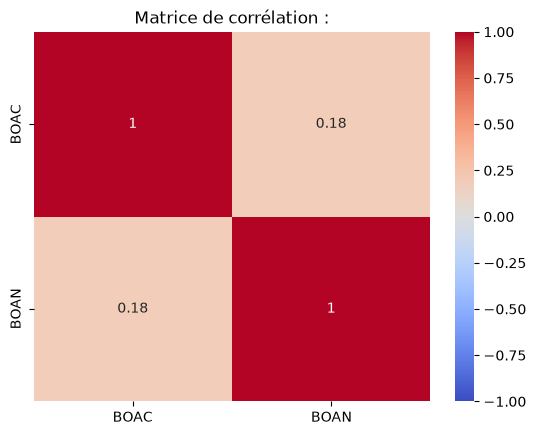

In [ ]:
# ON crée la heatmap de la matrice de corrélation avec seaborn
# "annot" affiche la valeur de la corrélation dans chaque case de la heatmap
# "coolwarm" sera la palette de couleur utilisée pour la heatmap (rouge à bleu)
# "vmin" et "vmax" sont les valeurs minimales et maximales de la corrélation (de -1 à 1 pour qu'elle soit plus générale)

heatmap = sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)

# On titre la heatmap
heatmap.set_title("Matrice de corrélation :")

- Pour simplifier les étapes de la création de la heatmap, on crée la fonction :

```
def mtr_corr(tickers : list[str], time : int, OHLC : str = "Close", map : bool = True) -> pd.DataFrame
```

Le paramètre "map" renvoie soit une matrice de corrélation ordinaire, soit une de corrélation visuelle.

- Cette fonction combine les fonctions :

```
download_tickers()
sns.heatmap()
```

In [22]:
def mtr_corr(tickers : list[str], time : int, OHLC : str = "Close", map : bool = True) -> pd.DataFrame :

    # On télécharge l'historique des tickers et on le stocke dans un dataframe
    df = download_tickers(tickers, time, OHLC = OHLC)

    if map == True :

        heatmap = sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0, vmin = -1, vmax = 1)
        heatmap.set_title("Matrice de corrélation :")
        
        return heatmap

    else :
        return df.corr()

#### Test : mtr_corr()

In [19]:
tickers = ["BOAC", "BOAN", "BOAB", "BOAS"]

In [23]:
mtr_corr(tickers, 100, map = False)

,BOAC,BOAN,BOAB,BOAS
BOAC,1.000000,0.182261,0.127350,0.331642
BOAN,0.182261,1.000000,0.104749,0.313909
BOAB,0.127350,0.104749,1.000000,0.126953
BOAS,0.331642,0.313909,0.126953,1.000000


<Axes: title={'center': 'Matrice de corrélation :'}>

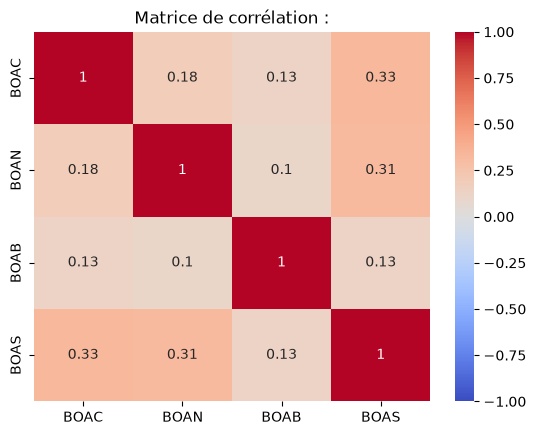

In [24]:
mtr_corr(tickers, 100, map = True)

----